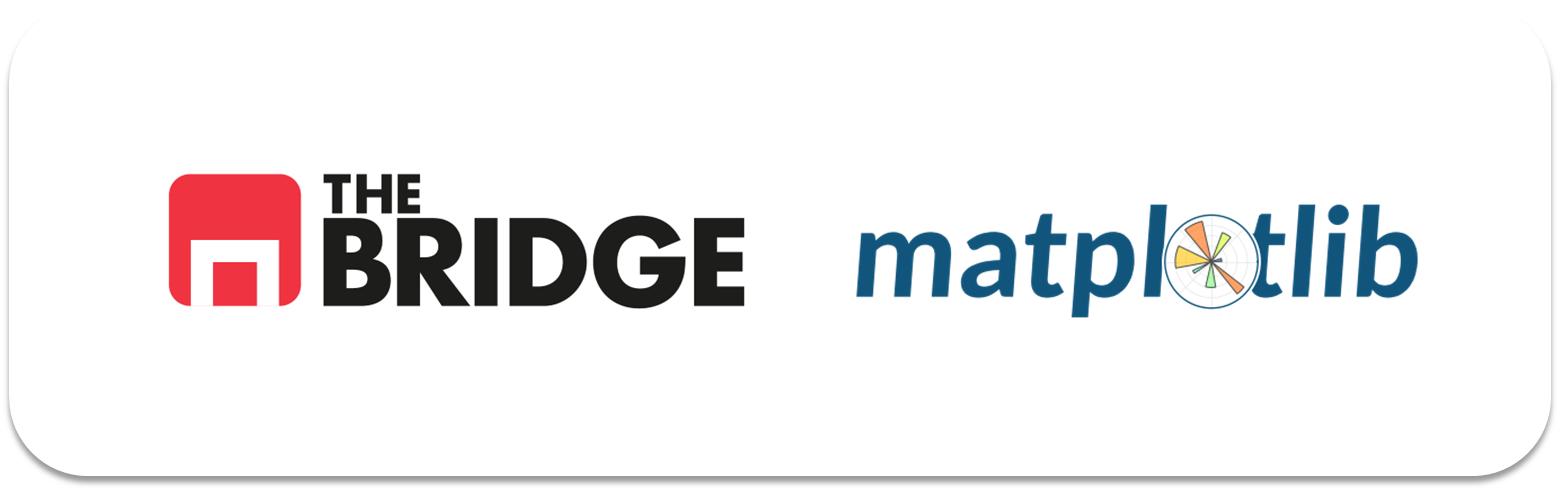

## PRACTICA OBLIGATORIA: **Visualización Básica**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de construcción de gráficas. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


### Ejercicio 1

#### #1.1

- Carga el dataset de casas de California que está en la ruta "./data/california_cities.csv".  
- Muestra parte de su contenido y su descripción.  
- Deshazte de las filas con nulos.

In [2]:
df = pd.read_csv("./data/california_cities.csv")
df.head()

,Unnamed: 0,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
0,0,Adelanto,34.576111,-117.432778,875.0,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03
1,1,AgouraHills,34.153333,-118.761667,281.0,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37
2,2,Alameda,37.756111,-122.274444,NaN,33.0,75467,22.960,10.611,12.349,59.465,27.482,31.983,53.79
3,3,Albany,37.886944,-122.297778,NaN,43.0,18969,5.465,1.788,3.677,14.155,4.632,9.524,67.28
4,4,Alhambra,34.081944,-118.135000,150.0,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01


In [3]:
print(df.describe())

       Unnamed: 0        latd       longd  elevation_m  elevation_ft  \
count  482.000000  482.000000  482.000000   434.000000    470.000000   
mean   240.500000   36.095088 -119.837714   180.416705    567.168723   
std    139.285678    2.298006    2.147676   309.531825   1001.265722   
min      0.000000   32.578333 -124.263333   -34.000000   -180.000000   
25%    120.250000   33.977292 -121.954931    22.000000     69.000000   
50%    240.500000   36.204722 -119.708611    67.000000    200.000000   
75%    360.750000   37.886667 -117.977292   173.500000    515.000000   
max    481.000000   41.965000 -114.596389  2402.000000   7880.000000   

       population_total  area_total_sq_mi  area_land_sq_mi  area_water_sq_mi  \
count      4.820000e+02        480.000000       482.000000        481.000000   
mean       6.489493e+04         18.442183        16.840981          1.589630   
std        2.032041e+05         36.363230        32.694647          9.490386   
min        1.000000e+00        

In [4]:
df.dropna(inplace=True)

In [5]:
print(df.isnull().sum())

Unnamed: 0            0
city                  0
latd                  0
longd                 0
elevation_m           0
elevation_ft          0
population_total      0
area_total_sq_mi      0
area_land_sq_mi       0
area_water_sq_mi      0
area_total_km2        0
area_land_km2         0
area_water_km2        0
area_water_percent    0
dtype: int64


#### #1.2  

Recrea la siguiente figura, para ello construye en apartados separados cada gráfico y luego haz un apartado en el que se junten los cuatro.  

Las figuras son:
1. Las ciudades más pobladas, con los numeros de las poblaciones (tendrás que usar texto y recordar que para centrarlos se necesita poner el argumento `ha` a "center" o investigar como funciona bar_label). Los colores de las barras deben tener un 50% de transparencia y ser: azul, gris, rojo, aceituna y marrón.  

2. Histograma del área total ocupada por las ciudades. (50 bins, fuente = "Arial", tamaño = 14, peso = "Bold", color azul acero o "steelblue")
3. El scatter de área de agua de un ciudad con su poblacion. Transparencia al 50% y color verde.
4. El boxplot de la altura de las ciudades.

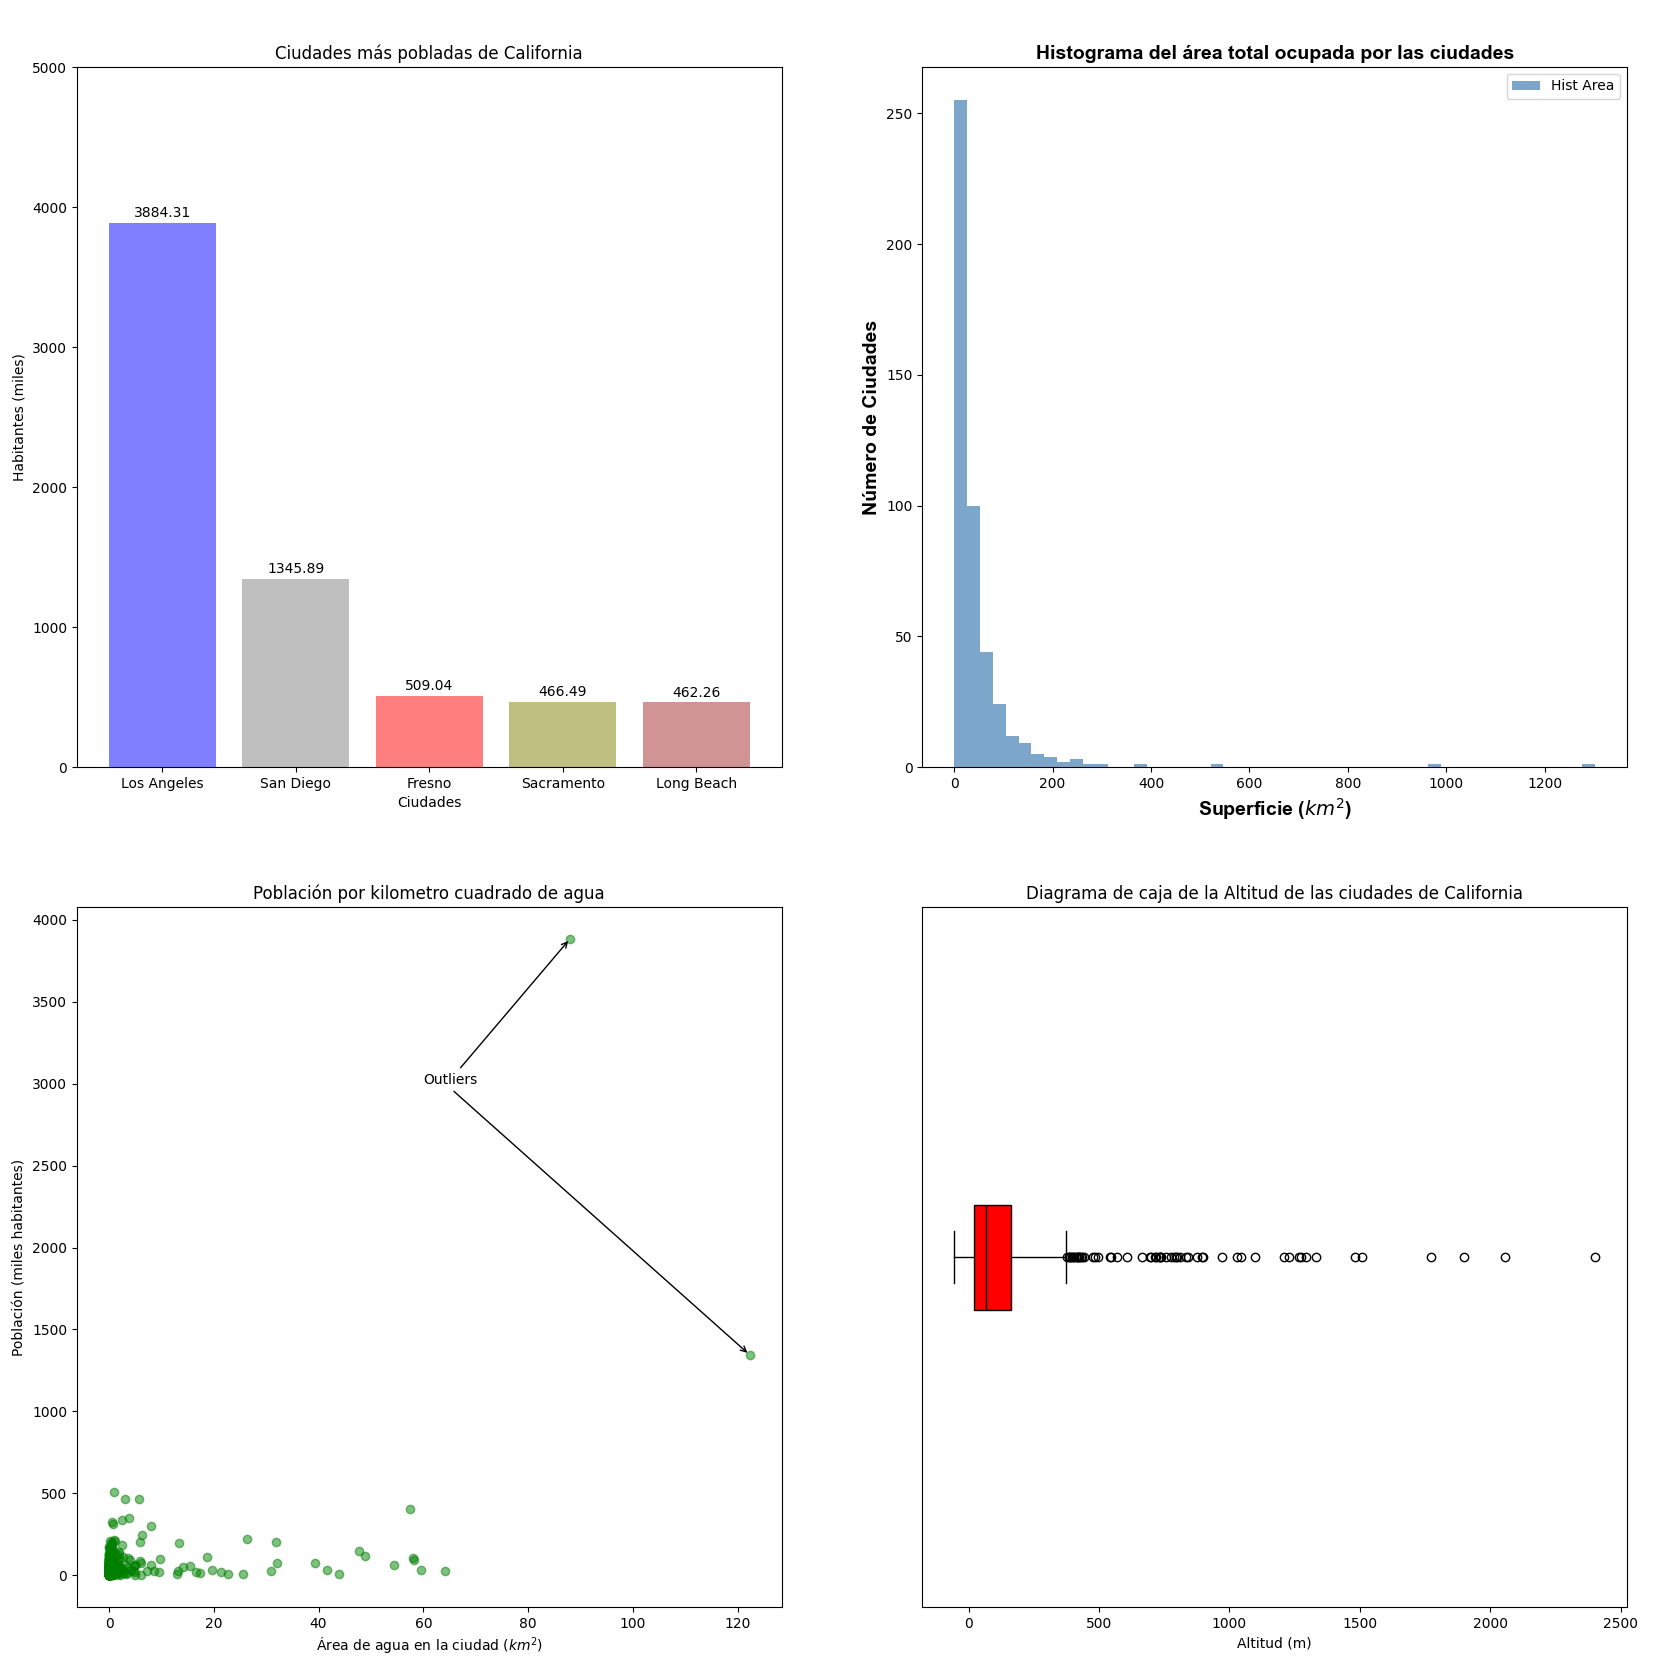

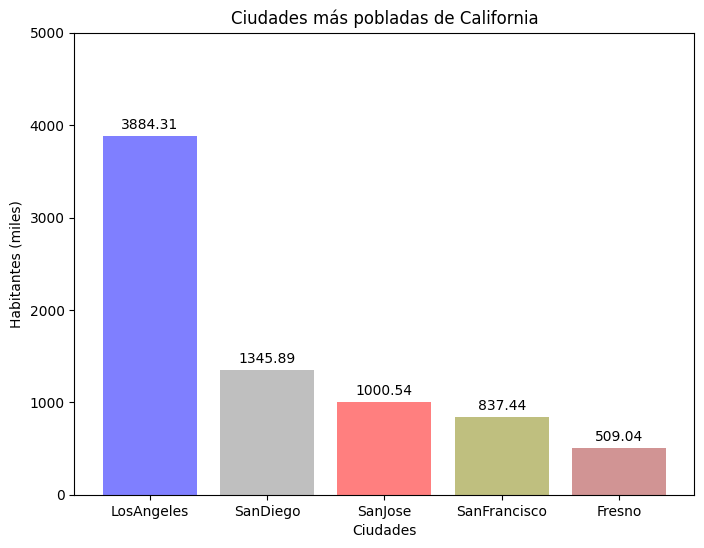

In [8]:
df = pd.read_csv("./data/california_cities.csv")
top_5 = df.nlargest(5, 'population_total')

colors = ['blue', 'grey', 'red', 'olive', 'brown']
labels = top_5['population_total'] / 1000

plt.figure(figsize=(8, 6))
bars = plt.bar(top_5['city'], labels, color=colors, alpha=0.5)

plt.bar_label(bars, fmt='%.2f', padding=3, label_type='edge') 

plt.title('Ciudades más pobladas de California')
plt.xlabel('Ciudades')
plt.ylabel('Habitantes (miles)')
plt.ylim(0, 5000)
plt.show()

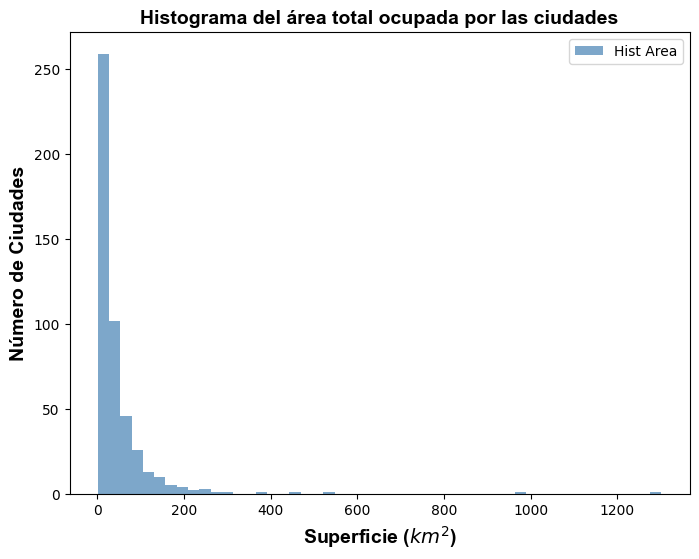

In [9]:
plt.figure(figsize=(8, 6))
plt.hist(df['area_total_km2'].dropna(), bins=50, color='steelblue', alpha=0.7, label='Hist Area')

font_style = {'family': 'Arial', 'size': 14, 'weight': 'bold'}

plt.title('Histograma del área total ocupada por las ciudades', fontdict=font_style)
plt.xlabel('Superficie ($km^2$)', fontdict=font_style)
plt.ylabel('Número de Ciudades', fontdict=font_style)
plt.legend()
plt.show()

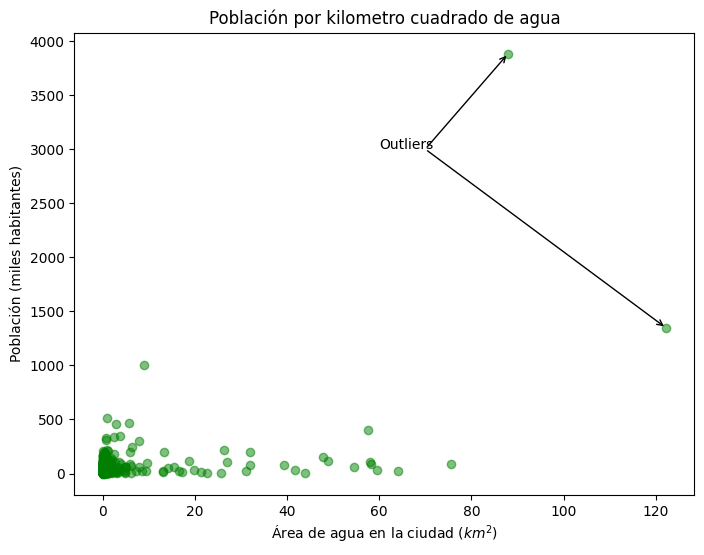

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(df['area_water_km2'], df['population_total']/1000, color='green', alpha=0.5)

outliers = df.nlargest(2, 'population_total')
for i, row in outliers.iterrows():
    plt.annotate('', xy=(row['area_water_km2'], row['population_total']/1000), 
                 xytext=(70, 3000), arrowprops=dict(arrowstyle='->', color='black'))

plt.text(60, 3000, 'Outliers', fontsize=10)
plt.title('Población por kilometro cuadrado de agua')
plt.xlabel('Área de agua en la ciudad ($km^2$)')
plt.ylabel('Población (miles habitantes)')
plt.show()

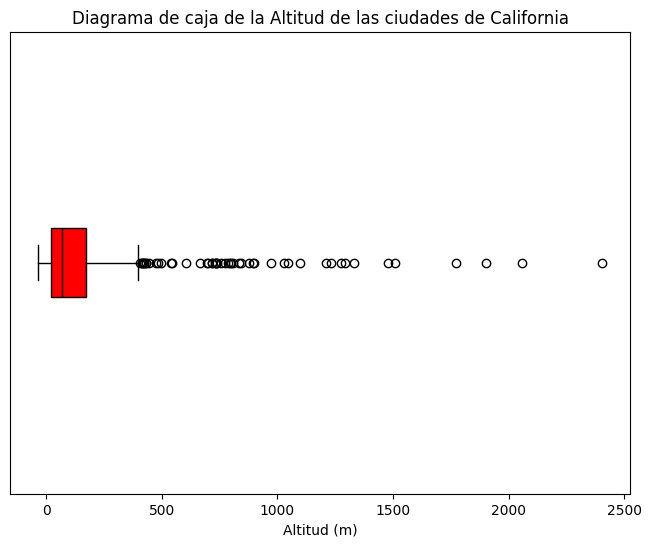

In [11]:
plt.figure(figsize=(8, 6))
plt.boxplot(df['elevation_m'].dropna(), vert=False, patch_artist=True, 
            boxprops=dict(facecolor='red'), medianprops=dict(color='black'))

plt.title('Diagrama de caja de la Altitud de las ciudades de California')
plt.xlabel('Altitud (m)')
plt.yticks([])
plt.show()

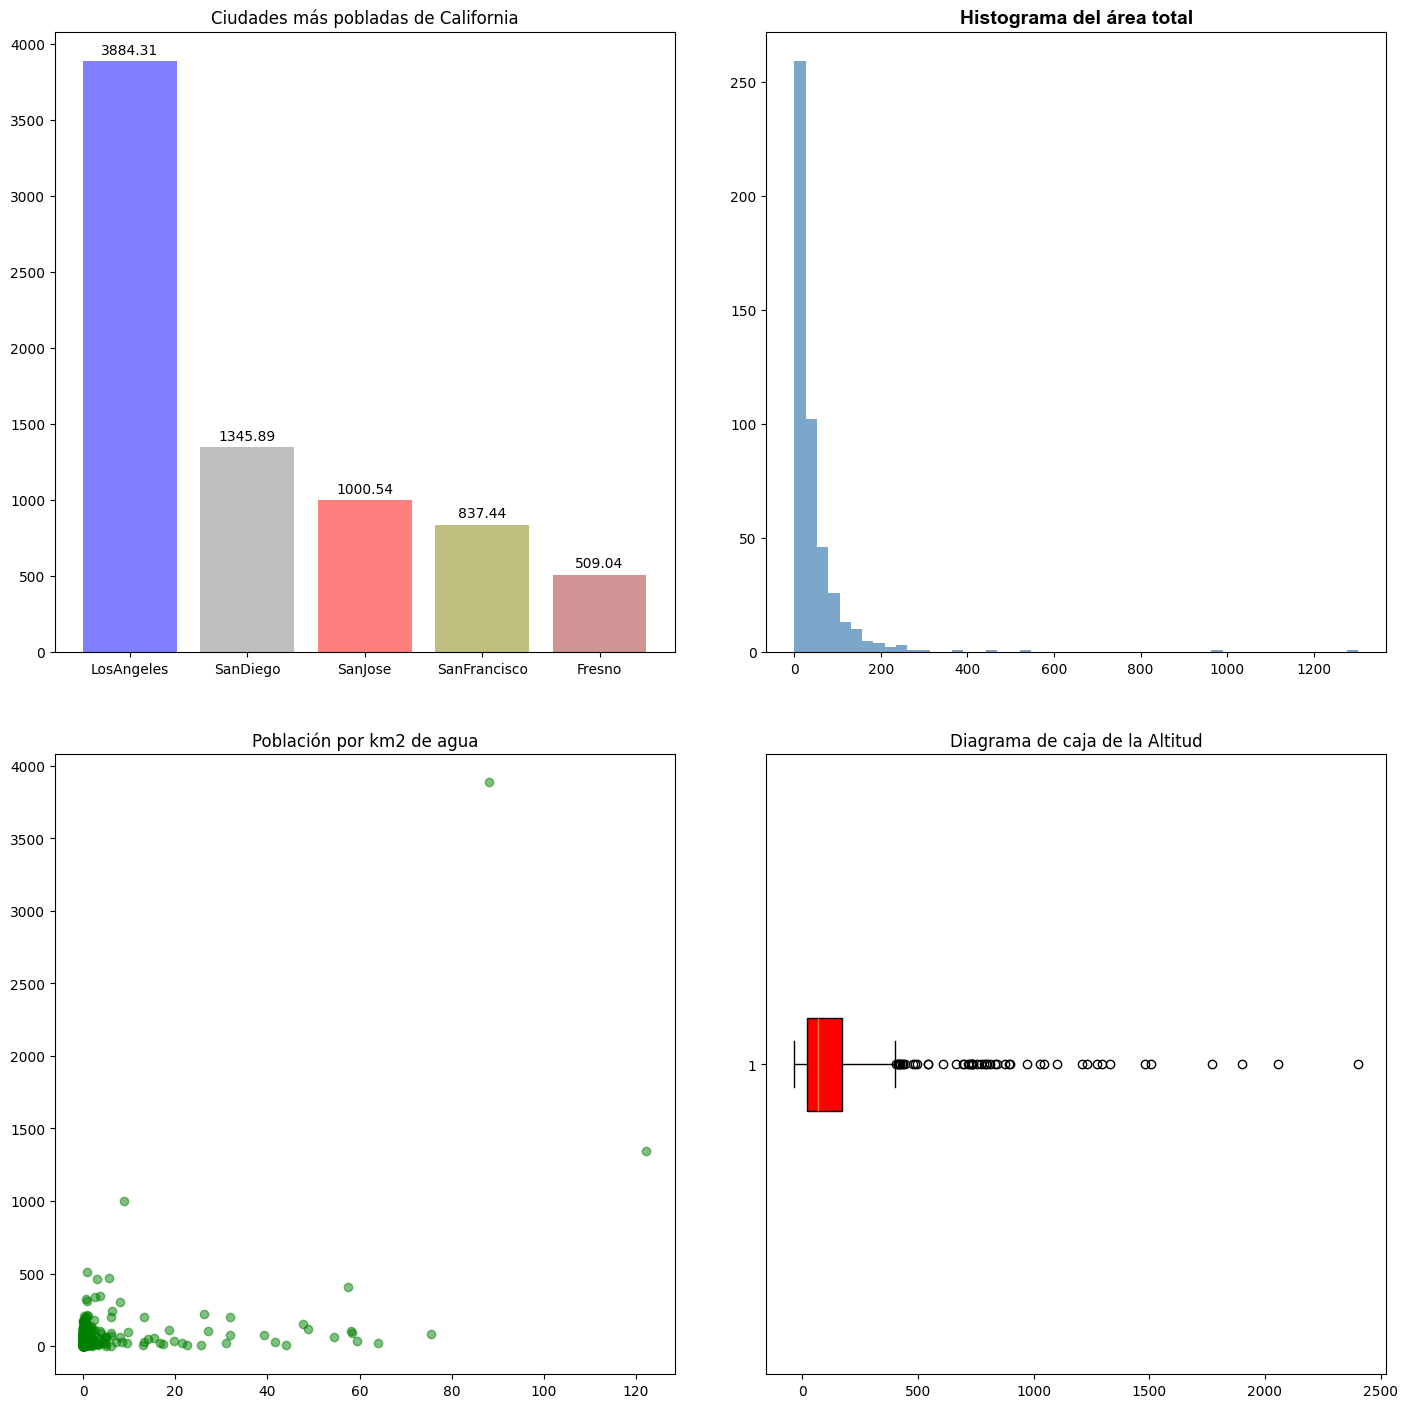

In [14]:
fig, axs = plt.subplots(2, 2, figsize=(15, 15))

bars1 = axs[0, 0].bar(top_5['city'], labels, color=colors, alpha=0.5)
axs[0, 0].bar_label(bars1, fmt='%.2f', padding=3)
axs[0, 0].set_title('Ciudades más pobladas de California')

axs[0, 1].hist(df['area_total_km2'].dropna(), bins=50, color='steelblue', alpha=0.7)
axs[0, 1].set_title('Histograma del área total', fontname='Arial', fontweight='bold', fontsize=14)

axs[1, 0].scatter(df['area_water_km2'], df['population_total']/1000, color='green', alpha=0.5)
axs[1, 0].set_title('Población por km2 de agua')

axs[1, 1].boxplot(df['elevation_m'].dropna(), vert=False, patch_artist=True, boxprops=dict(facecolor='red'))
axs[1, 1].set_title('Diagrama de caja de la Altitud')

plt.tight_layout(pad=4.0)
plt.savefig("mi_grafica_final.png", dpi=300, bbox_inches='tight')
plt.show()


#### #1.3

Graba la figura en un archivo .png y sube el archivo a tu repositorio personal junto con el notebook.